# Bar Path Model Testing

Predict exercise data using saved model

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from os import path
import pickle as pkl
import matplotlib.pyplot as plt
import numpy as np

DATA_COLUMNS = ['AccX', 'AccY', 'AccZ', 'VelX', 'VelY', 'VelZ', 'PosX', 'PosY', 'PosZ', 'Pitch', 'Roll', 'Yaw']

### Load data and config

In [3]:
from utils import load_data, load_config

data = load_data()
config = load_config()
data.head()

Fetching data from Airtable...
Formula: AND({ValidData} = 'true', {StartRepTime} != '', {EndRepTime} != '', {Reps} >= '1')
Found 511 matches


,Date,Exercise,Lifter,WorkoutTime,Reps,Weight,Intensity,Notes,StartRepTime,EndRepTime,Counter,TimeBetweenSamples,AccX,AccY,AccZ,Pitch,Roll,Yaw,HeartRate
0,"Jul 17, 2024 at 8:37:11 PM",DB Side Raise,Anwar,32.25,9,27.5,9,None,4.38,26.48,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[663011, 9, 9, 10, 10, 10, 13, 7, 10, 10, 10, ...","[-0.327, 0.068, 0.159, -0.036, -0.125, -0.051,...","[-0.15, -0.236, -0.011, 0.169, 0.05, -0.098, -...","[0.03, 0.009, -0.077, -0.052, 0.05, 0.151, 0.1...","[0.346, 0.346, 0.347, 0.347, 0.348, 0.348, 0.3...","[0.093, 0.093, 0.092, 0.092, 0.092, 0.092, 0.0...","[-0.016, -0.016, -0.015, -0.015, -0.015, -0.01...","[110, 110, 110, 110, 110, 110, 110, 110, 110, ..."
1,"May 20, 2024 at 1:44:48 PM",Bench,Anwar,47.67,7,195,10,None,21.12,40.38,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[258264, 7, 9, 9, 10, 10, 10, 10, 11, 9, 10, 1...","[0.13, -0.052, -0.069, -0.006, -0.048, 0.075, ...","[-0.17, -0.157, -0.054, -0.044, -0.078, -0.024...","[0.147, 0.036, -0.106, -0.231, -0.274, -0.156,...","[0.15, 0.15, 0.151, 0.151, 0.152, 0.152, 0.152...","[0.059, 0.059, 0.058, 0.058, 0.058, 0.058, 0.0...","[-0.004, -0.004, -0.003, -0.002, -0.002, -0.00...","[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9..."
2,"Apr 16, 2024 at 4:45:01 PM",Horizontal Chest Press,Anwar,28.69,8,145,10,None,6.72,25.34,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[222003, 10, 9, 10, 10, 10, 12, 7, 10, 10, 10,...","[0.254, 0.409, -0.13, -0.019, 0.234, 0.331, 0....","[0.819, -0.072, -0.617, -1.169, -0.67, 0.128, ...","[0.095, 0.315, 0.715, 0.66, 0.735, 0.698, 0.82...","[0.667, 0.674, 0.676, 0.683, 0.694, 0.704, 0.7...","[0.057, 0.059, 0.063, 0.068, 0.074, 0.078, 0.0...","[-0.02, -0.022, -0.027, -0.034, -0.038, -0.04,...","[84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 84, 8..."
3,"Apr 27, 2024 at 11:07:05 AM",Squat,Anwar,46.75,7,225,9,None,16.08,39.98,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[242417, 13, 7, 9, 11, 9, 10, 10, 10, 12, 8, 1...","[0.119, -0.129, -0.155, -0.134, -0.003, 0.076,...","[0.138, -0.047, -0.156, -0.166, -0.181, -0.138...","[0.152, 0.149, 0.097, 0.144, 0.222, 0.199, 0.0...","[0.526, 0.528, 0.529, 0.529, 0.528, 0.527, 0.5...","[0.023, 0.022, 0.022, 0.022, 0.022, 0.022, 0.0...","[-0.006, -0.005, -0.005, -0.005, -0.004, -0.00...","[124, 124, 124, 124, 124, 124, 124, 124, 124, ..."
4,"Mar 2, 2024 at 3:35:29 PM",DB Side Raise,Anwar,32.91,12,27.5,8,None,4.05,30.96,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[95273, 10, 11, 11, 8, 11, 10, 9, 11, 9, 10, 1...","[-0.151, 0.003, -0.038, 0.02, 0.008, -0.123, -...","[0.203, 0.355, 0.324, 0.137, 0.029, -0.009, 0....","[-0.006, -0.054, -0.154, -0.193, -0.148, -0.10...","[0.401, 0.402, 0.403, 0.404, 0.405, 0.405, 0.4...","[0.123, 0.124, 0.124, 0.124, 0.124, 0.123, 0.1...","[-0.025, -0.025, -0.024, -0.023, -0.023, -0.02...","[123, 123, 123, 123, 123, 123, 123, 123, 123, ..."


## Test the exercise classifier on a random sample

### Load the classifier

In [4]:
classifier_file = path.join(config['ExercisesFolder'], config['ClassifierFilename'])
with open(classifier_file, 'rb') as f:
    exercise_clf = pkl.load(f)

### Predict a random record and plot

Prediction: [1]
Actual: Bench


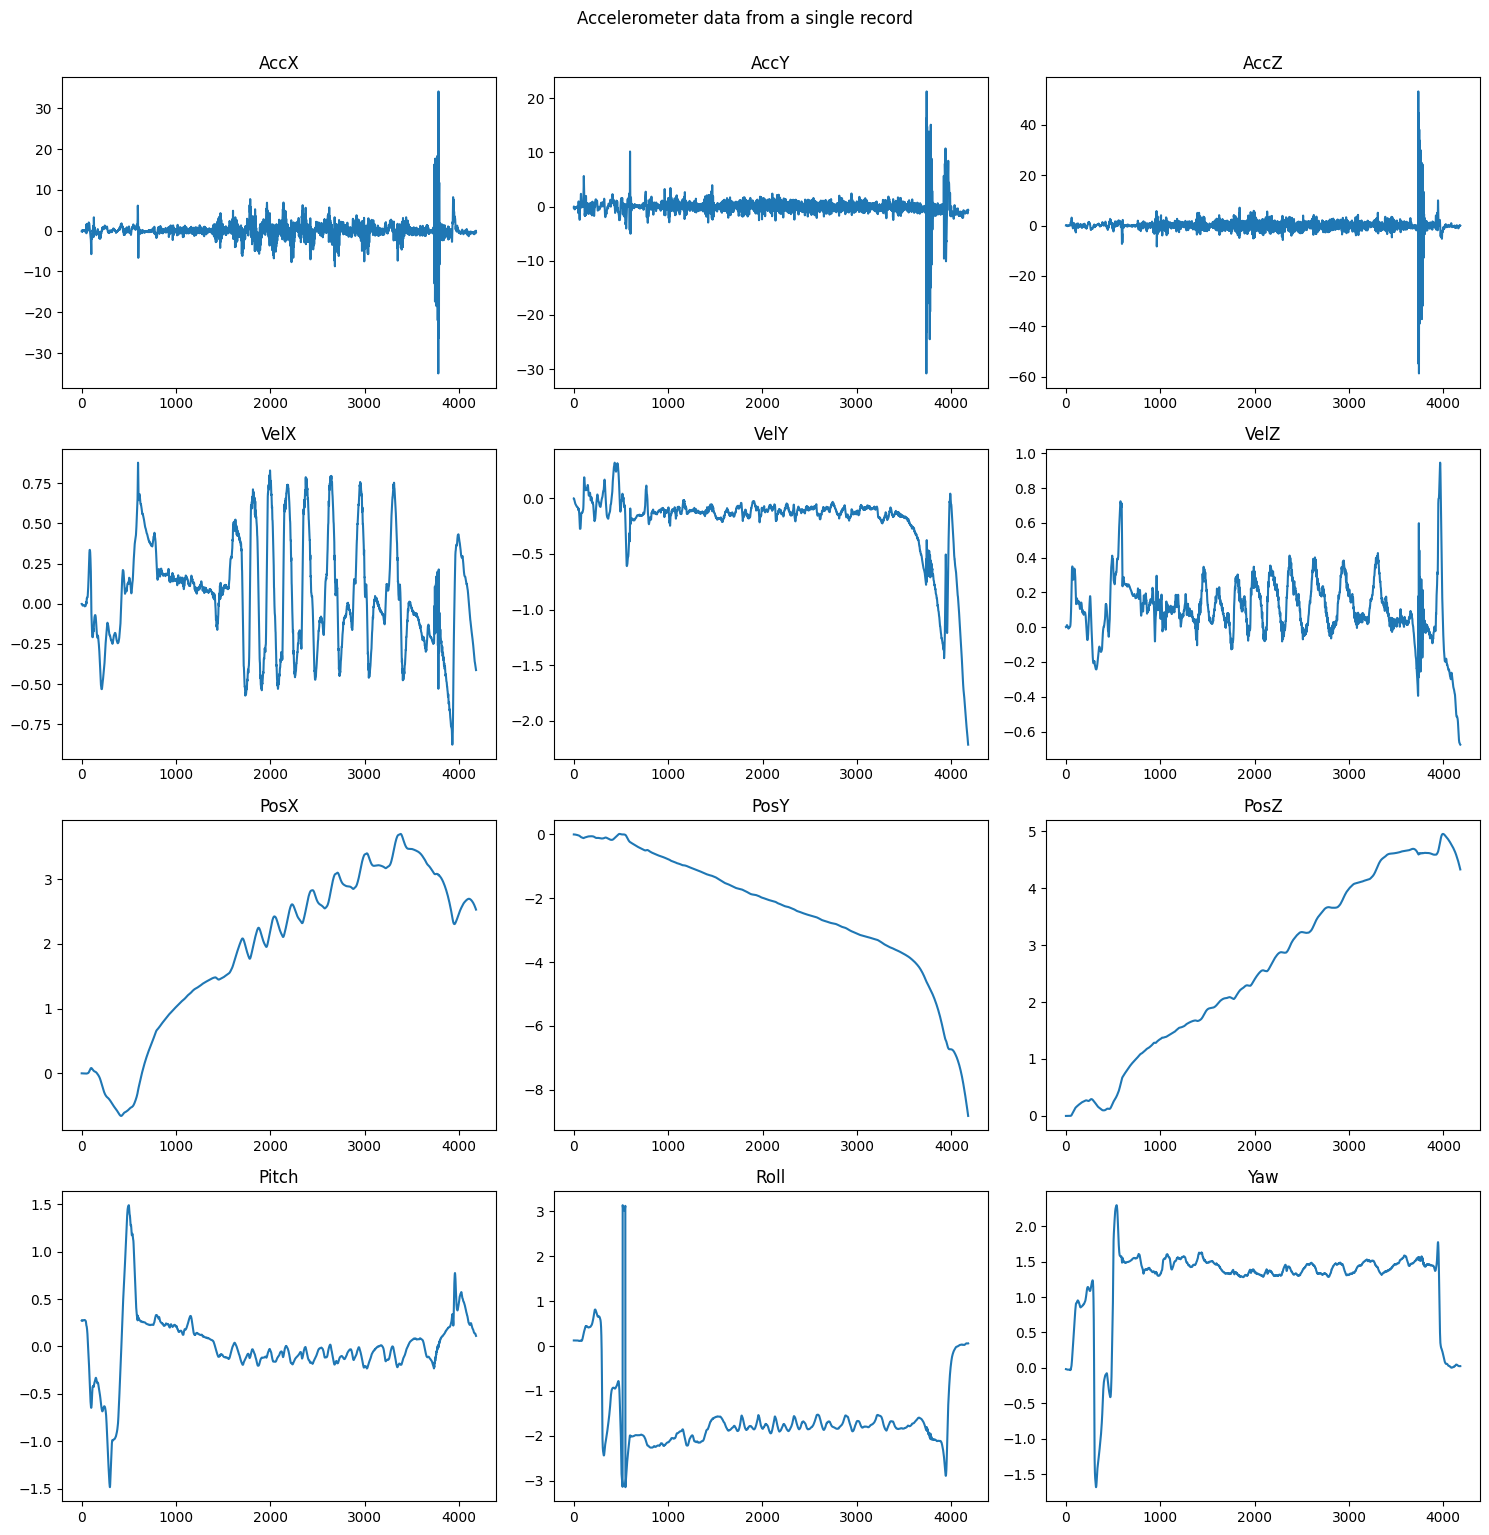

In [5]:
from preprocessing import preprocess_data, extract_features

record = data.sample(1)
record = preprocess_data(record, config['CutoffFreq'], config['SampleRate'])
features = extract_features(record)
prediction = exercise_clf.predict(features)

print(f"Prediction: {prediction}")
print(f"Actual: {record['Exercise'].values[0]}")

fig, axs = plt.subplots(4, 3, figsize=(15, 15))

for i, ax in enumerate(axs.flat):
    plot_data = np.concatenate(record[DATA_COLUMNS[i]].to_numpy())
    ax.plot(plot_data)
    ax.set_title(DATA_COLUMNS[i])

plt.tight_layout()
plt.suptitle('Accelerometer data from a single record', y=1.02)
plt.show()

#### Plot the data

## Predict the rep start and stop of a random sample

### Load the classifier

In [6]:
classifier_file = path.join(config['RepsFolder'], config['ClassifierFilename'])
with open(classifier_file, 'rb') as f:
    rep_clf = pkl.load(f)

### Predict a random record

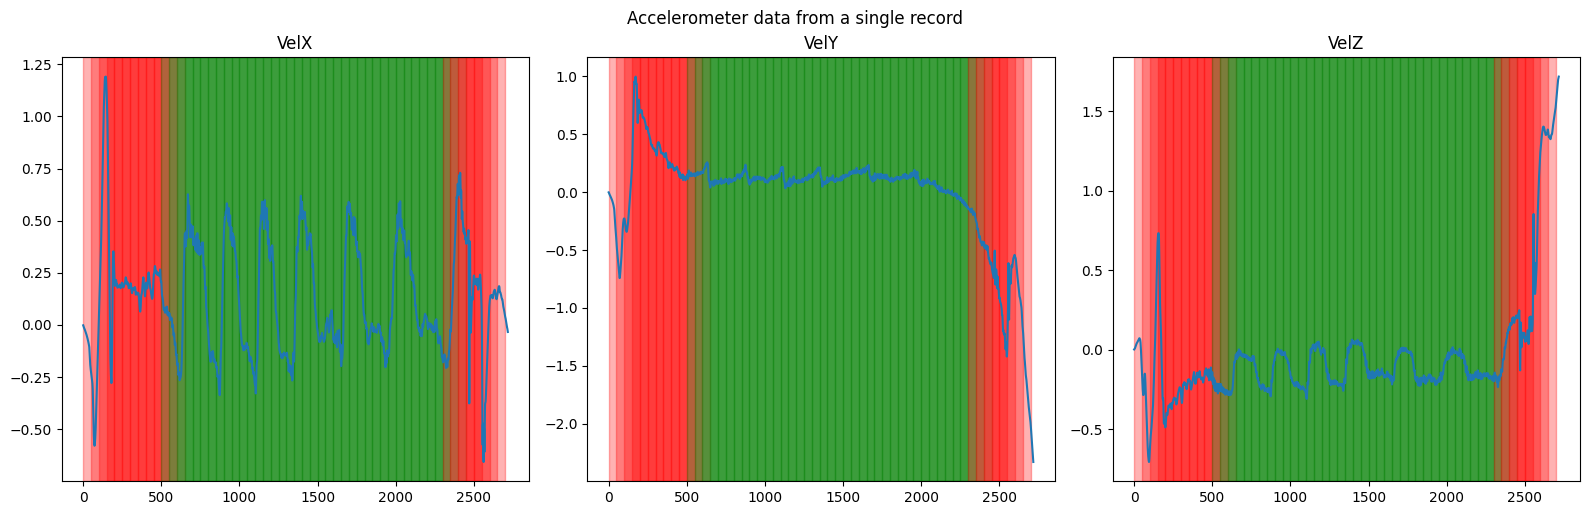

In [7]:
from preprocessing import extract_window_features

record = data.sample(1)
record = preprocess_data(record, config['CutoffFreq'], config['SampleRate'])

window_features = extract_window_features(record, config['WindowLength'], config['WindowStride'])
predictions = rep_clf.predict(window_features)


fig, axs = plt.subplots(1, 3, figsize=(16, 5))

VEL_COLUMNS = ['VelX', 'VelY', 'VelZ']

for i, ax in enumerate(axs.flat):
    plot_data = np.concatenate(record[VEL_COLUMNS[i]].to_numpy())
    ax.plot(plot_data)
    ax.set_title(VEL_COLUMNS[i])
    for j in range(len(predictions)):
        ax.axvspan(j * config['WindowStride'], j * config['WindowStride'] + config['WindowLength'], color='green' if predictions[j] == 1 else 'red', alpha=0.3)

plt.tight_layout()
plt.suptitle('Accelerometer data from a single record', y=1.02)
plt.show()

### Predict start and end times

In [8]:
from postprocessing import predict_exercise_times

start_predict, end_predict = predict_exercise_times(
    predictions, config['WindowLength'], config['WindowStride'], config['SampleRate'])
start_actual = float(record['StartRepTime'].values[0])
end_actual = float(record['EndRepTime'].values[0])

print(f"Predicted start: {start_predict}, actual start: {start_actual}")
print(f"Predicted end: {end_predict}, actual end: {end_actual}")

start_diff = abs(start_predict - start_actual)
end_diff = abs(end_predict - end_actual)

print(f"Start difference: {start_diff:.3f}")
print(f"End difference: {end_diff:.3f}")

Predicted start: 4.5, actual start: 5.58
Predicted end: 27.5, actual end: 22.04
Start difference: 1.080
End difference: 5.460


## Calculate start time predictions for all data

In [ ]:
data = preprocess_data(data, config['CutoffFreq'], config['SampleRate'])

In [12]:
config = load_config()

### Calculate error for each record

In [10]:
start_errors = []
end_errors = []

for i in range(len(data)):
    record = data.loc[[i]]
    window_features = extract_window_features(record, config['WindowLength'], config['WindowStride'])
    predictions = rep_clf.predict(window_features)
    start_predict, end_predict = predict_exercise_times(
        predictions, config['WindowLength'], config['WindowStride'], config['SampleRate'], config['MinConsqWindows'])
    start_actual = float(record['StartRepTime'].values[0])
    end_actual = float(record['EndRepTime'].values[0])
    start_error = abs(start_predict - start_actual)
    end_error = abs(end_predict - end_actual)
    start_errors.append(start_error)
    end_errors.append(end_error)

start_errors = np.array(start_errors)
end_errors = np.array(end_errors)

### Log the results

In [11]:
start_avg_error = np.mean(start_errors)
end_avg_error = np.mean(end_errors)

print(f"Average start error: {start_avg_error:.3f}")
print(f"Average end error: {end_avg_error:.3f}")

from datetime import datetime
from utils import load_config

config = load_config()
results_file = path.join(config['ResultsFolder'], config['ResultsFilename'])

with open(results_file, 'a') as f:
    f.write(f"{datetime.now()}\n")
    f.write(f"Average start error: {start_avg_error:.3f}\n")
    f.write(f"Average end error: {end_avg_error:.3f}\n")
    f.write(f"Window length: {config['WindowLength']}\n")
    f.write(f"Window stride: {config['WindowStride']}\n")
    f.write(f"Min consecutive windows: {config['MinConsqWindows']}\n\n")

Average start error: 3.098
Average end error: 5.582
